**Student ID:** `24018029`  
**GitHub Repo:** `https://github.com/OguzhanCel/YZM-2011-Project`  
**File:** `p3_classification_24018029.ipynb`

**Track chosen: A — Classification**

# 1. Recap & Task Definition

**Problem & dataset.** We are predicting blood hemoglobin concentration from short (1–2 min) face videos using rPPG. The dataset contains 361 usable recordings. In P1 we extracted a `30 × N_frames` time-series per video (6 facial landmarks × 5 colour channels: R, G, B, Cr, C) and in P2 we aggregated each series into 60 base features (mean + std per channel), engineered 100 additional features, and trained linear regressors. The best P2 model (Lasso) achieved Test R² ≈ 0.56 and MAE ≈ 0.70 g/dL.

**Classification target.** We define a clinically motivated binary target **`is_anemic`** using WHO gender-specific thresholds:
- Female (is_male = 0): Hb < 12.0 g/dL → **anemic (1)**
- Male   (is_male = 1): Hb < 13.0 g/dL → **anemic (1)**

This framing is exactly the screening question the model would answer in practice: "Is this person likely anemic?"

**Class distribution** will be reported after loading the data.

# 2. Data Preparation

In [1]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    silhouette_score, davies_bouldin_score, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings('ignore')
np.seterr(divide='ignore', over='ignore', invalid='ignore')  # suppress matmul overflow
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RNG = 42
np.random.seed(RNG)

### 2.1 Load aggregated data & rebuild features (identical to P2)

In [2]:
DATA_DIR   = 'data'
EXCEL_PATH = 'info.xlsx'
HB_COLUMN  = 'Deger'
CACHE_CSV  = 'agg_df_v2.csv'

POINT_NAMES = ['N1_cene_sol', 'N2_sol_yanak_ic3', 'N3_sag_yanak_ic3',
               'N4_alin_ust_orta', 'N5_dudak_ustu', 'N6_cene_sag']
CHANNELS    = ['R', 'G', 'B', 'Cr', 'C']
ROW_LABELS  = [f'{pt}_{ch}' for pt in POINT_NAMES for ch in CHANNELS]

GENDER_MAP = {'e':1,'k':0,'m':1,'f':0,'erkek':1,'kadın':0,'kadin':0,
              'male':1,'female':0,'1':1,'0':0,'true':1,'false':0}

def to_is_male(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    if s in GENDER_MAP: return GENDER_MAP[s]
    try:
        f = float(s)
        if f in (0.0, 1.0): return int(f)
    except ValueError: pass
    return np.nan

def build_agg_df():
    npy_files = sorted(Path(DATA_DIR).glob('*.npy'))
    xl = pd.read_excel(EXCEL_PATH)
    gender_col = next((c for c in ['Cinsiyet','cinsiyet','CINSIYET'] if c in xl.columns), None)
    hb_values     = xl[HB_COLUMN].values
    gender_values = xl[gender_col].values if gender_col else [np.nan]*len(hb_values)
    rows = []
    for i, npf in enumerate(npy_files):
        if i >= len(hb_values): break
        hb = hb_values[i]
        if pd.isna(hb): continue
        m = np.load(npf)
        row = {'video_id': npf.stem, 'hemoglobin': float(hb),
               'is_male': to_is_male(gender_values[i])}
        for r_idx, label in enumerate(ROW_LABELS):
            row[f'{label}_mean'] = float(m[r_idx].mean())
            row[f'{label}_std']  = float(m[r_idx].std())
        rows.append(row)
    return pd.DataFrame(rows)

if Path(CACHE_CSV).exists():
    agg_df = pd.read_csv(CACHE_CSV)
    print(f'Loaded cached agg_df from {CACHE_CSV}')
else:
    agg_df = build_agg_df()
    agg_df.to_csv(CACHE_CSV, index=False)
    print(f'Built agg_df from {DATA_DIR}/ and saved to {CACHE_CSV}')

agg_df = agg_df.dropna(subset=['is_male']).reset_index(drop=True)
agg_df['is_male'] = agg_df['is_male'].astype(int)
print(f'Shape: {agg_df.shape}')
agg_df.head()

Loaded cached agg_df from agg_df_v2.csv
Shape: (361, 63)


,video_id,hemoglobin,is_male,N1_cene_sol_R_mean,N1_cene_sol_R_std,N1_cene_sol_G_mean,N1_cene_sol_G_std,N1_cene_sol_B_mean,N1_cene_sol_B_std,N1_cene_sol_Cr_mean,...,N6_cene_sag_R_mean,N6_cene_sag_R_std,N6_cene_sag_G_mean,N6_cene_sag_G_std,N6_cene_sag_B_mean,N6_cene_sag_B_std,N6_cene_sag_Cr_mean,N6_cene_sag_Cr_std,N6_cene_sag_C_mean,N6_cene_sag_C_std
0,hem001,13.4,1,124.377518,2.680179,110.051178,2.626354,107.065895,3.631660,135.405869,...,131.040375,2.604594,112.701752,2.652660,108.148354,3.880506,137.539505,0.602914,167.717636,3.743280
1,hem002,12.6,1,104.375694,23.563869,85.765945,21.408920,79.057411,22.147329,137.850281,...,133.869797,20.851192,102.572510,23.108624,92.775101,26.707579,144.445175,2.543290,196.464386,18.746725
2,hem003,13.5,1,131.284790,4.934799,112.853630,4.433036,109.120125,5.068303,137.519119,...,129.956802,4.699675,107.441010,4.973872,101.642441,5.584442,139.729324,0.601211,174.988388,5.010877
3,hem004,13.5,1,146.309036,3.623675,124.449921,3.112890,113.170479,3.613783,139.846588,...,176.727997,10.163269,150.679291,8.670785,139.898071,10.258175,141.900864,1.193529,228.825378,13.877372
4,hem005,13.9,1,134.568207,0.927083,112.447662,1.004554,100.523277,1.373231,140.029724,...,155.590652,1.453719,129.726379,1.361239,118.801682,1.754752,141.820328,0.306628,207.319199,2.141227


### 2.2 Feature engineering (same families as P2)

In [3]:
eps = 1e-3
def safe(series, lo=0.01, hi=0.99):
    a = pd.Series(series).replace([np.inf, -np.inf], np.nan)
    if a.isna().all(): return a
    q_lo, q_hi = a.quantile(lo), a.quantile(hi)
    return a.clip(q_lo, q_hi)

for pt in POINT_NAMES:
    agg_df[f'{pt}_R_mean_x_male'] = safe(agg_df[f'{pt}_R_mean'] * agg_df['is_male'])

for pt in POINT_NAMES:
    R = agg_df[f'{pt}_R_mean']
    agg_df[f'{pt}_GR_ratio']  = safe(agg_df[f'{pt}_G_mean']  / (R + eps))
    agg_df[f'{pt}_BR_ratio']  = safe(agg_df[f'{pt}_B_mean']  / (R + eps))
    agg_df[f'{pt}_CrR_ratio'] = safe(agg_df[f'{pt}_Cr_mean'] / (R + eps))

for label in ROW_LABELS:
    agg_df[f'{label}_cv'] = safe(agg_df[f'{label}_std'] / (agg_df[f'{label}_mean'] + eps))

for label in ROW_LABELS:
    agg_df[f'{label}_mean_x_std'] = safe(agg_df[f'{label}_mean'] * agg_df[f'{label}_std'])

for ch in CHANNELS:
    mean_cols = [f'{pt}_{ch}_mean' for pt in POINT_NAMES]
    std_cols  = [f'{pt}_{ch}_std'  for pt in POINT_NAMES]
    agg_df[f'face_{ch}_mean_avg'] = agg_df[mean_cols].mean(axis=1)
    agg_df[f'face_{ch}_std_avg']  = agg_df[std_cols].mean(axis=1)

raw_base = [c for c in agg_df.columns
            if c not in ['video_id', 'hemoglobin', 'is_male']
            and not c.endswith(('_GR_ratio','_BR_ratio','_CrR_ratio','_cv',
                                '_mean_x_std','_mean_avg','_std_avg','_x_male'))]
corr_with_y = agg_df[raw_base].corrwith(agg_df['hemoglobin']).abs().sort_values(ascending=False)
top5 = corr_with_y.head(5).index.tolist()
for c in top5:
    agg_df[f'{c}_sq'] = safe(agg_df[c] ** 2)

all_features = [c for c in agg_df.columns if c not in ['video_id', 'hemoglobin']]
agg_df = agg_df.replace([np.inf, -np.inf], np.nan).dropna(subset=all_features + ['hemoglobin'])
print(f'Total features after engineering: {len(all_features)}')
print(f'Clean dataset shape: {agg_df.shape}')

Total features after engineering: 160
Clean dataset shape: (361, 162)


### 2.3 Define classification target

Class distribution:
  Normal  (0): 164  (45.4%)
  Anemic  (1): 197  (54.6%)
  Ratio   : 1:0.83


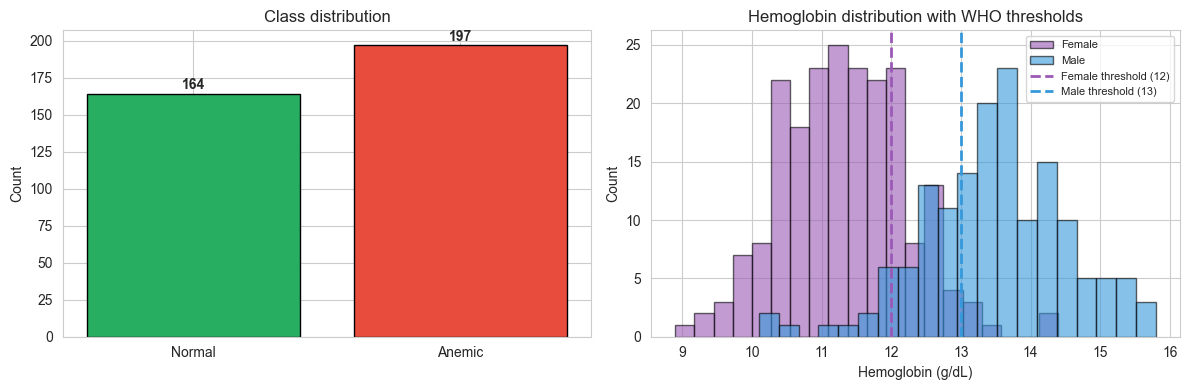

In [4]:
agg_df['is_anemic'] = np.where(
    agg_df['is_male'] == 1,
    (agg_df['hemoglobin'] < 13.0).astype(int),
    (agg_df['hemoglobin'] < 12.0).astype(int)
)

print('Class distribution:')
counts = agg_df['is_anemic'].value_counts()
print(f'  Normal  (0): {counts[0]}  ({counts[0]/len(agg_df):.1%})')
print(f'  Anemic  (1): {counts[1]}  ({counts[1]/len(agg_df):.1%})')
print(f'  Ratio   : 1:{counts[0]/counts[1]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Normal', 'Anemic'], [counts[0], counts[1]],
            color=['#27ae60', '#e74c3c'], edgecolor='black')
axes[0].set_ylabel('Count'); axes[0].set_title('Class distribution')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

for g, label, color in [(0, 'Female', '#9b59b6'), (1, 'Male', '#3498db')]:
    sub = agg_df[agg_df['is_male'] == g]
    axes[1].hist(sub['hemoglobin'], bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
axes[1].axvline(12.0, color='#9b59b6', ls='--', lw=2, label='Female threshold (12)')
axes[1].axvline(13.0, color='#3498db', ls='--', lw=2, label='Male threshold (13)')
axes[1].set_xlabel('Hemoglobin (g/dL)'); axes[1].set_ylabel('Count')
axes[1].set_title('Hemoglobin distribution with WHO thresholds')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.4 Train / Test split

We use an **80/20 train/test split** (stratified by `is_male`, `random_state=42`). Unlike P2's 60/20/20 three-way split, we merge the former validation set into training to maximise the data available for learning. Model selection and hyperparameter tuning are handled entirely by **5-fold stratified cross-validation** inside `GridSearchCV`, which is more robust than a fixed 72-sample validation set.

This gives us **288 training** samples (vs. 216 before) and **73 test** samples.

In [5]:
X = agg_df[all_features].values
y = agg_df['is_anemic'].values
strat = agg_df['is_male'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=strat)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'y_train class balance: {np.bincount(y_train)}')
print(f'y_test  class balance: {np.bincount(y_test)}')

Train: (288, 160)  |  Test: (73, 160)
y_train class balance: [130 158]
y_test  class balance: [34 39]


### 2.5 Feature selection (Lasso-based, carried from P2)

In P2, LassoCV zeroed out 146 of 160 features. We replicate this: fit LassoCV on the training hemoglobin values (regression), identify non-zero features, and combine with the top-20 mutual-information features for the classification target.

In [6]:
# Hemoglobin values for the same train split
y_hb_all = agg_df['hemoglobin'].values
_, _, y_hb_train, _ = train_test_split(
    X, y_hb_all, test_size=0.20, random_state=RNG, stratify=strat)

kf = KFold(n_splits=5, shuffle=True, random_state=RNG)
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 80), cv=kf, max_iter=50000,
                    random_state=RNG).fit(X_train_s, y_hb_train)

lasso_coefs = pd.Series(lasso_cv.coef_, index=all_features)
kept_mask = lasso_coefs != 0
lasso_features = lasso_coefs[kept_mask].sort_values(key=np.abs, ascending=False)

print(f'Lasso alpha = {lasso_cv.alpha_:.4g}')
print(f'Kept {kept_mask.sum()} / {len(all_features)} features:')
print(lasso_features.round(4))
lasso_feat_names = lasso_features.index.tolist()

Lasso alpha = 0.08154
Kept 9 / 160 features:
is_male                           0.8501
N1_cene_sol_B_mean_sq             0.1026
N1_cene_sol_Cr_mean              -0.0717
N5_dudak_ustu_CrR_ratio           0.0685
N4_alin_ust_orta_R_mean_x_male    0.0462
N2_sol_yanak_ic3_Cr_mean         -0.0418
N4_alin_ust_orta_R_std           -0.0115
N1_cene_sol_R_mean_x_male         0.0003
N1_cene_sol_GR_ratio              0.0001
dtype: float64


Lasso survivors: 9
MI top-20:       20
Union (selected): 23
X_train_sel: (288, 23)  |  X_test_sel: (73, 23)


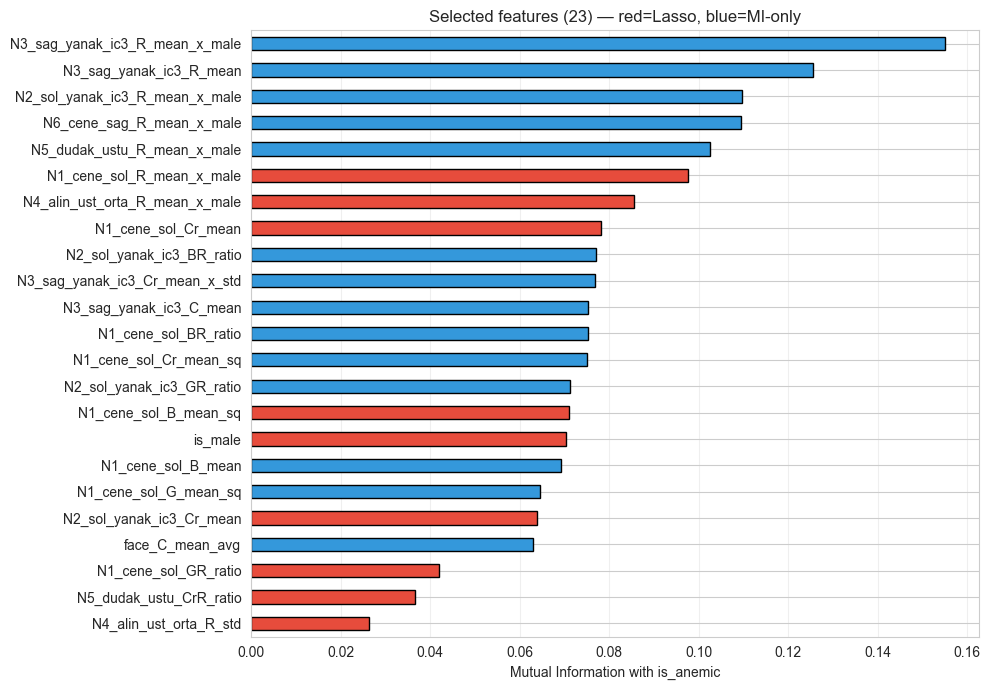

In [7]:
mi_scores = mutual_info_classif(X_train_s, y_train, random_state=RNG)
mi_series = pd.Series(mi_scores, index=all_features).sort_values(ascending=False)

mi_top = mi_series.head(20).index.tolist()
selected_features = list(dict.fromkeys(lasso_feat_names + mi_top))
sel_idx = [all_features.index(f) for f in selected_features]

X_train_sel = X_train_s[:, sel_idx]
X_test_sel  = X_test_s[:, sel_idx]

print(f'Lasso survivors: {len(lasso_feat_names)}')
print(f'MI top-20:       {len(mi_top)}')
print(f'Union (selected): {len(selected_features)}')
print(f'X_train_sel: {X_train_sel.shape}  |  X_test_sel: {X_test_sel.shape}')

fig, ax = plt.subplots(figsize=(10, 7))
plot_feats = mi_series.reindex(selected_features).dropna().sort_values()
colors = ['#e74c3c' if f in lasso_feat_names else '#3498db' for f in plot_feats.index]
plot_feats.plot.barh(ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information with is_anemic')
ax.set_title(f'Selected features ({len(selected_features)}) — red=Lasso, blue=MI-only')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Unsupervised Analysis

## 3.1 Dimensionality Reduction with PCA

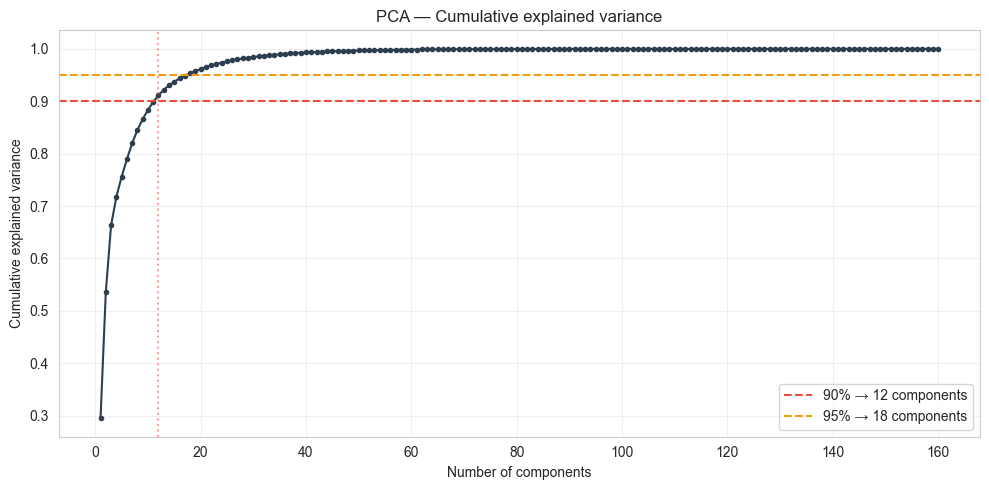

Components for 90% variance: 12
Components for 95% variance: 18
First 2 components explain: 53.6% of variance


In [8]:
pca_full = PCA(random_state=RNG).fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.searchsorted(cum_var, 0.90) + 1
n_95 = np.searchsorted(cum_var, 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var)+1), cum_var, 'o-', markersize=3, color='#2c3e50')
ax.axhline(0.90, color='#e74c3c', ls='--', label=f'90% → {n_90} components')
ax.axhline(0.95, color='#f39c12', ls='--', label=f'95% → {n_95} components')
ax.axvline(n_90, color='#e74c3c', ls=':', alpha=0.5)
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Cumulative explained variance'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'First 2 components explain: {cum_var[1]:.1%} of variance')

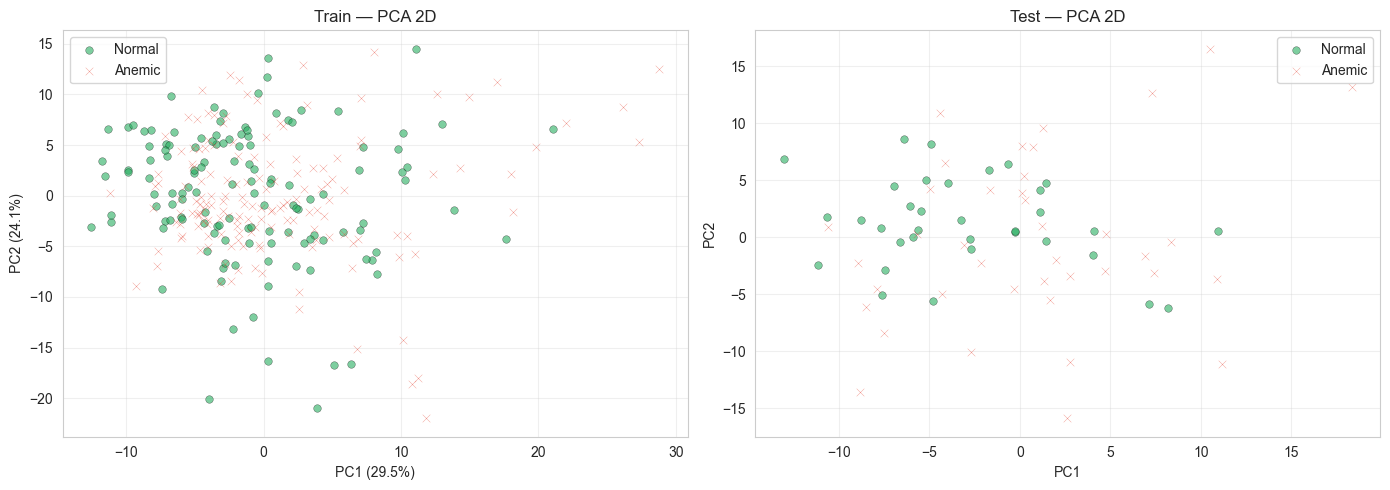

In [9]:
pca_2d = PCA(n_components=2, random_state=RNG).fit(X_train_s)
Z_train = pca_2d.transform(X_train_s)
Z_test  = pca_2d.transform(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls, label, color, marker in [(0,'Normal','#27ae60','o'),(1,'Anemic','#e74c3c','x')]:
    mask = y_train == cls
    axes[0].scatter(Z_train[mask,0], Z_train[mask,1], c=color, label=label,
                    alpha=0.6, s=30, marker=marker, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Train — PCA 2D'); axes[0].legend(); axes[0].grid(alpha=0.3)

for cls, label, color, marker in [(0,'Normal','#27ae60','o'),(1,'Anemic','#e74c3c','x')]:
    mask = y_test == cls
    axes[1].scatter(Z_test[mask,0], Z_test[mask,1], c=color, label=label,
                    alpha=0.6, s=30, marker=marker, edgecolors='k', linewidths=0.3)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Test — PCA 2D'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Discussion:** The PCA projection shows partial separability between the anemic and normal classes along PC1, driven by `is_male` and its interaction features. However, significant overlap exists — the classes are not linearly separable in 2D — indicating that nonlinear classifiers and more components are needed.

## 3.2 Clustering

We apply two clustering algorithms — **K-Means** and **DBSCAN** — on the PCA-reduced selected features (training data only). We tune key hyperparameters and evaluate with Silhouette Score and Davies-Bouldin Index.

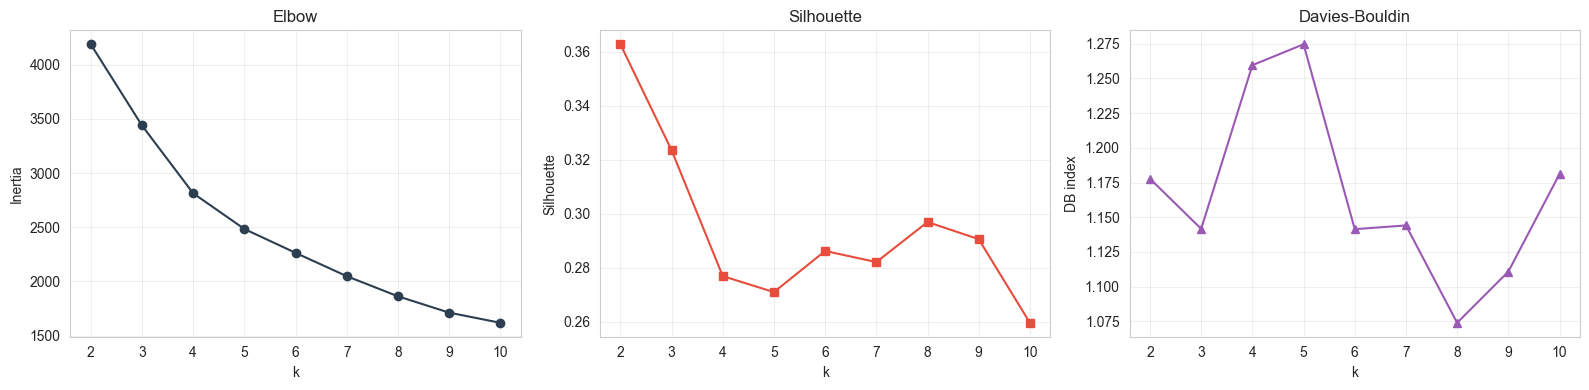

Best k by silhouette: 2  (score = 0.3628)


In [10]:
n_clust_comp = min(n_90, X_train_sel.shape[1])
pca_clust = PCA(n_components=n_clust_comp, random_state=RNG).fit(X_train_sel)
X_train_pca = pca_clust.transform(X_train_sel)
X_test_pca  = pca_clust.transform(X_test_sel)

K_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X_train_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_pca, km.labels_))
    db_scores.append(davies_bouldin_score(X_train_pca, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_range, inertias, 'o-', color='#2c3e50')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow'); axes[0].grid(alpha=0.3)
axes[1].plot(K_range, silhouettes, 's-', color='#e74c3c')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette'); axes[1].grid(alpha=0.3)
axes[2].plot(K_range, db_scores, '^-', color='#9b59b6')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB index'); axes[2].set_title('Davies-Bouldin'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f'Best k by silhouette: {best_k}  (score = {max(silhouettes):.4f})')

K-Means (k=2): Silhouette=0.3628, Davies-Bouldin=1.1777


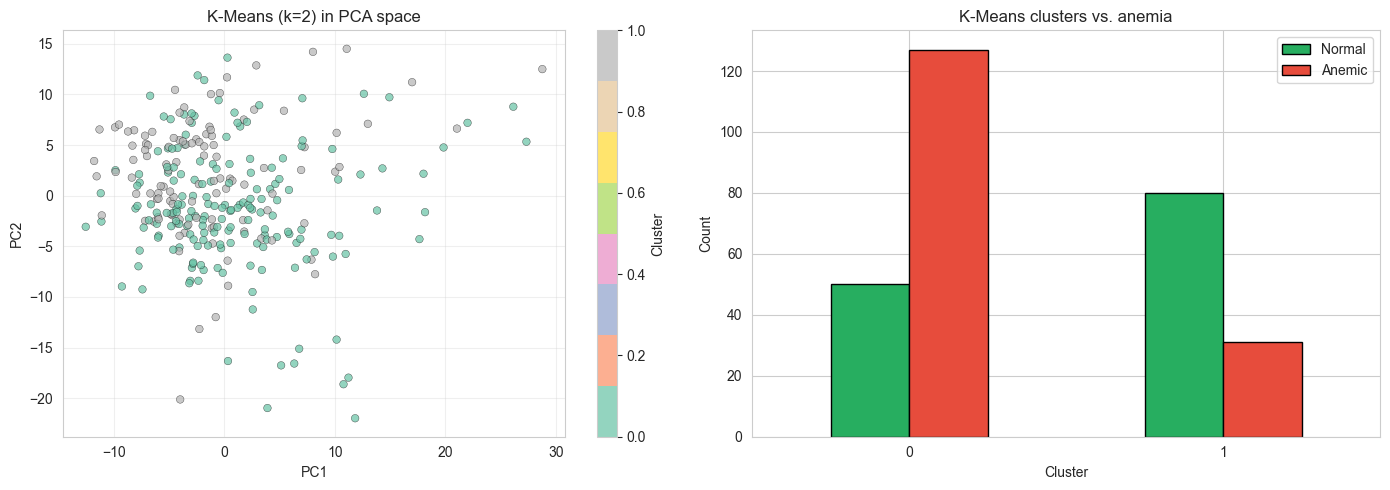


Cross-tabulation:
is_anemic   0    1
Cluster           
0          50  127
1          80   31


In [11]:
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=RNG).fit(X_train_pca)
km_labels = km_best.labels_
sil_km = silhouette_score(X_train_pca, km_labels)
db_km  = davies_bouldin_score(X_train_pca, km_labels)
print(f'K-Means (k={best_k}): Silhouette={sil_km:.4f}, Davies-Bouldin={db_km:.4f}')

Z_train_2d = pca_2d.transform(X_train_s)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(Z_train_2d[:,0], Z_train_2d[:,1], c=km_labels,
                     cmap='Set2', alpha=0.7, s=30, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means (k={best_k}) in PCA space')
plt.colorbar(sc, ax=axes[0], label='Cluster'); axes[0].grid(alpha=0.3)

ct = pd.crosstab(km_labels, y_train, rownames=['Cluster'], colnames=['is_anemic'])
ct.plot.bar(ax=axes[1], color=['#27ae60','#e74c3c'], edgecolor='black')
axes[1].set_title('K-Means clusters vs. anemia'); axes[1].set_ylabel('Count')
axes[1].legend(['Normal','Anemic']); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
print('\nCross-tabulation:'); print(ct)

### 3.2.2 DBSCAN

In [12]:
# Tune DBSCAN: sweep eps and min_samples
from itertools import product as iterproduct

eps_range = np.arange(0.5, 5.1, 0.5)
ms_range  = [3, 5, 7, 10, 15]
dbscan_results = []

for ep, ms in iterproduct(eps_range, ms_range):
    db = DBSCAN(eps=ep, min_samples=ms).fit(X_train_pca)
    labels = db.labels_
    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    # Need at least 2 clusters and not all noise for metrics
    if n_clusters >= 2 and n_noise < len(labels) * 0.5:
        # Exclude noise points for silhouette
        mask = labels != -1
        sil = silhouette_score(X_train_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_train_pca[mask], labels[mask])
        dbscan_results.append({'eps': ep, 'min_samples': ms,
                               'n_clusters': n_clusters, 'n_noise': n_noise,
                               'silhouette': sil, 'db_index': dbi})

if dbscan_results:
    dbscan_df = pd.DataFrame(dbscan_results)
    print(f'Valid configurations found: {len(dbscan_df)}')
    print(dbscan_df.sort_values('silhouette', ascending=False).head(10).to_string(index=False))
    best_db_row = dbscan_df.loc[dbscan_df['silhouette'].idxmax()]
    print(f"\nBest DBSCAN: eps={best_db_row['eps']}, min_samples={int(best_db_row['min_samples'])}")
    print(f"  Clusters={int(best_db_row['n_clusters'])}, Noise={int(best_db_row['n_noise'])}")
    print(f"  Silhouette={best_db_row['silhouette']:.4f}, DB={best_db_row['db_index']:.4f}")
else:
    print('No valid DBSCAN configuration found (all produced <2 clusters or too much noise).')
    best_db_row = None

Valid configurations found: 20
 eps  min_samples  n_clusters  n_noise  silhouette  db_index
 2.0           15           2      143    0.589670  0.587173
 2.0            7           2       85    0.470659  0.885049
 2.0           10           3      109    0.452445  0.715713
 2.5           15           2       51    0.438322  0.960640
 2.5           10           2       45    0.428483  0.984042
 2.5            7           2       38    0.415382  1.019974
 3.0           15           2       29    0.410186  1.034302
 3.0           10           2       18    0.388951  1.097879
 3.5           15           2       13    0.377781  1.132848
 3.0            7           2       12    0.372988  1.149257

Best DBSCAN: eps=2.0, min_samples=15
  Clusters=2, Noise=143
  Silhouette=0.5897, DB=0.5872


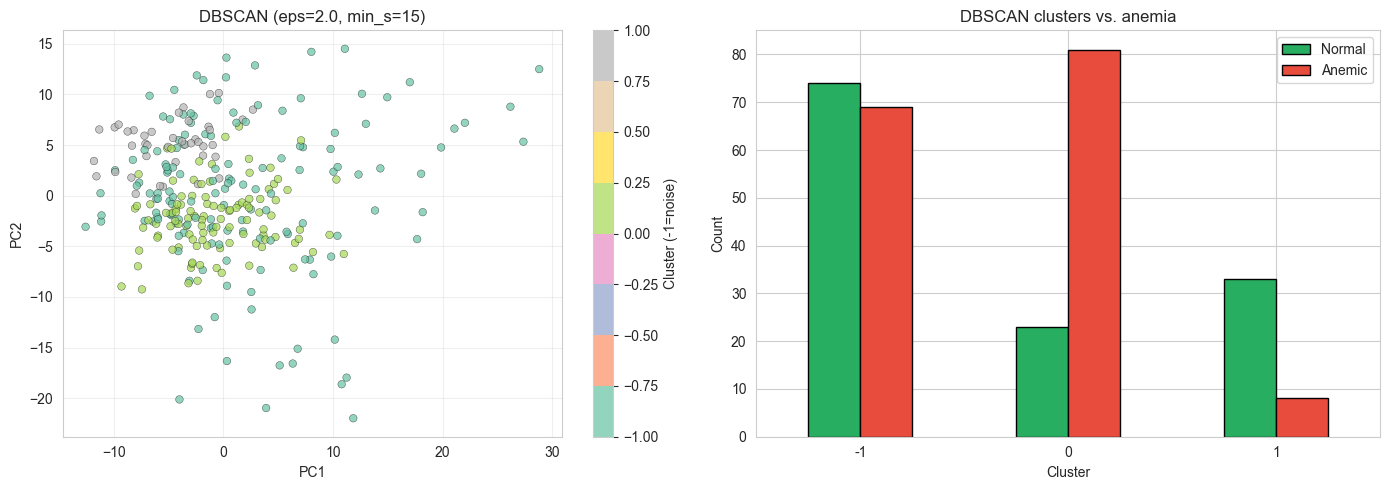


DBSCAN: Silhouette=0.5897, DB=0.5872
Cross-tabulation:
is_anemic   0   1
Cluster          
-1         74  69
 0         23  81
 1         33   8


In [13]:
# Fit best DBSCAN and visualize
if best_db_row is not None:
    db_best = DBSCAN(eps=best_db_row['eps'],
                     min_samples=int(best_db_row['min_samples'])).fit(X_train_pca)
    db_labels = db_best.labels_
    mask_valid = db_labels != -1
    sil_db = silhouette_score(X_train_pca[mask_valid], db_labels[mask_valid])
    db_db  = davies_bouldin_score(X_train_pca[mask_valid], db_labels[mask_valid])

    Z_train_2d = pca_2d.transform(X_train_s)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sc = axes[0].scatter(Z_train_2d[:,0], Z_train_2d[:,1], c=db_labels,
                         cmap='Set2', alpha=0.7, s=30, edgecolors='k', linewidths=0.3)
    axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
    axes[0].set_title(f"DBSCAN (eps={best_db_row['eps']}, min_s={int(best_db_row['min_samples'])})")
    plt.colorbar(sc, ax=axes[0], label='Cluster (-1=noise)'); axes[0].grid(alpha=0.3)

    ct_db = pd.crosstab(db_labels, y_train, rownames=['Cluster'], colnames=['is_anemic'])
    ct_db.plot.bar(ax=axes[1], color=['#27ae60','#e74c3c'], edgecolor='black')
    axes[1].set_title('DBSCAN clusters vs. anemia'); axes[1].set_ylabel('Count')
    axes[1].legend(['Normal','Anemic']); axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout(); plt.show()

    print(f'\nDBSCAN: Silhouette={sil_db:.4f}, DB={db_db:.4f}')
    print('Cross-tabulation:'); print(ct_db)
else:
    sil_db = -1
    db_db  = 999
    print('DBSCAN skipped — no valid config.')

### Clustering summary

In [14]:
rows = [{'Method': f'K-Means (k={best_k})', 'Silhouette': sil_km, 'Davies-Bouldin': db_km}]
if best_db_row is not None:
    rows.append({'Method': f"DBSCAN (eps={best_db_row['eps']}, ms={int(best_db_row['min_samples'])})",
                 'Silhouette': sil_db, 'Davies-Bouldin': db_db})
clust_summary = pd.DataFrame(rows).round(4)
print('Clustering comparison:')
print(clust_summary.to_string(index=False))

Clustering comparison:
                 Method  Silhouette  Davies-Bouldin
          K-Means (k=2)      0.3628          1.1777
DBSCAN (eps=2.0, ms=15)      0.5897          0.5872


## 3.3 Cluster Labels as a Feature

In [15]:
# K-Means has predict(); DBSCAN does not — so we use K-Means for the cluster feature
clust_train = km_best.predict(X_train_pca)
clust_test  = km_best.predict(X_test_pca)

X_train_clust = np.column_stack([X_train_sel, clust_train])
X_test_clust  = np.column_stack([X_test_sel,  clust_test])
print(f'Feature matrix with cluster: {X_train_clust.shape}')

Feature matrix with cluster: (288, 24)


# 4 & 5. Model Training & Hyperparameter Tuning

Six classifiers with `GridSearchCV` (5-fold stratified CV, scoring=F1 macro). All models trained on the **selected feature set** with 288 training samples. Cross-validation scores serve as the validation metric.

Key choices:
- **`class_weight='balanced'`** where supported — boosts recall for the anemic class
- **Wide hyperparameter grids** for ensemble methods

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

def eval_clf(name, model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model. Returns metrics dict."""
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        auc_test = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
    elif hasattr(model, 'decision_function'):
        auc_test = roc_auc_score(y_te, model.decision_function(X_te))
    else:
        auc_test = np.nan
    return {
        'Model': name,
        'Train Accuracy':  accuracy_score(y_tr, y_tr_pred),
        'Train F1 (macro)': f1_score(y_tr, y_tr_pred, average='macro'),
        'Test Accuracy':   accuracy_score(y_te, y_te_pred),
        'Test Precision':  precision_score(y_te, y_te_pred, zero_division=0),
        'Test Recall':     recall_score(y_te, y_te_pred, zero_division=0),
        'Test F1 (macro)': f1_score(y_te, y_te_pred, average='macro'),
        'Test AUC-ROC':    auc_test,
    }

results = []
tuned_models = {}
cv_scores = {}  # store CV F1 for the summary

### Logistic Regression

/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklea

Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 (macro): 0.7472


/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/oguz/projects/MLders/venv/lib/python3.9/site-packages/sklea

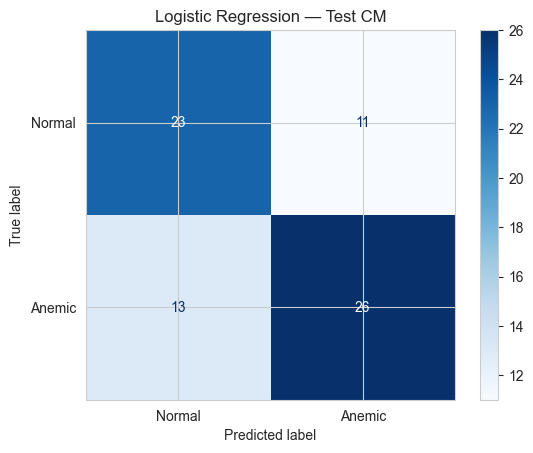

In [17]:
import logging
logging.getLogger('sklearn').setLevel(logging.ERROR)

param_lr = {'C': [0.001,0.01,0.1,1,10,100], 'penalty': ['l1','l2'], 'solver': ['liblinear'], 'class_weight': ['balanced',None]}
gs_lr = GridSearchCV(LogisticRegression(max_iter=5000, random_state=RNG), param_lr, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_lr.fit(X_train_sel, y_train)
tuned_models['Logistic Regression'] = gs_lr.best_estimator_
cv_scores['Logistic Regression'] = gs_lr.best_score_
print(f'Best params: {gs_lr.best_params_}')
print(f'Best CV F1 (macro): {gs_lr.best_score_:.4f}')

res = eval_clf('Logistic Regression', gs_lr.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_lr.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('Logistic Regression — Test CM'); plt.show()

### KNN

Best params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best CV F1 (macro): 0.7172


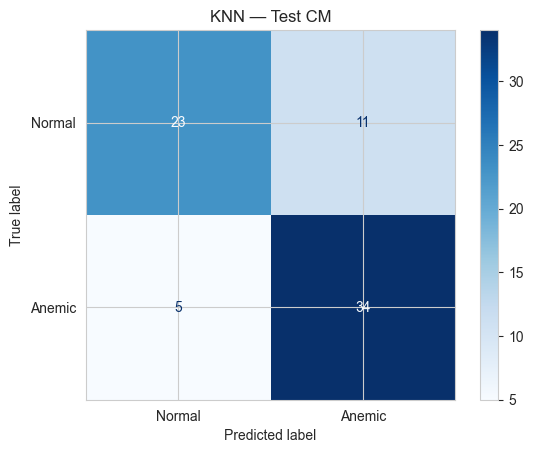

In [18]:
param_knn = {'n_neighbors': [3,5,7,11,15,21], 'metric': ['euclidean','manhattan'], 'weights': ['uniform','distance']}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_knn.fit(X_train_sel, y_train)
tuned_models['KNN'] = gs_knn.best_estimator_
cv_scores['KNN'] = gs_knn.best_score_
print(f'Best params: {gs_knn.best_params_}')
print(f'Best CV F1 (macro): {gs_knn.best_score_:.4f}')

res = eval_clf('KNN', gs_knn.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_knn.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('KNN — Test CM'); plt.show()

### Decision Tree

Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10}
Best CV F1 (macro): 0.7088


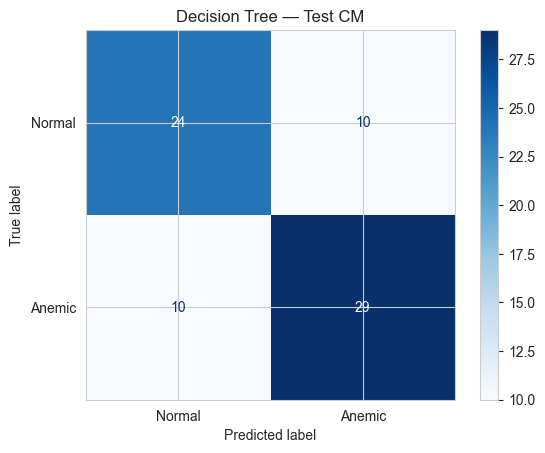

In [19]:
param_dt = {'max_depth': [2,3,5,7,10,None], 'min_samples_leaf': [1,3,5,10], 'criterion': ['gini','entropy'], 'class_weight': ['balanced',None]}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=RNG), param_dt, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_dt.fit(X_train_sel, y_train)
tuned_models['Decision Tree'] = gs_dt.best_estimator_
cv_scores['Decision Tree'] = gs_dt.best_score_
print(f'Best params: {gs_dt.best_params_}')
print(f'Best CV F1 (macro): {gs_dt.best_score_:.4f}')

res = eval_clf('Decision Tree', gs_dt.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_dt.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('Decision Tree — Test CM'); plt.show()

### SVM

Best params: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1 (macro): 0.7331


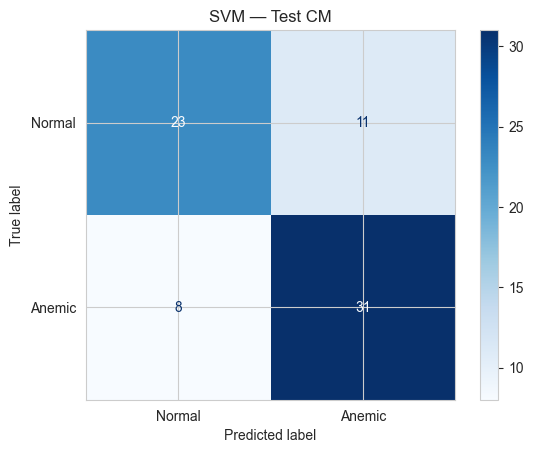

In [20]:
param_svm = {'C': [0.01,0.1,1,10,100], 'kernel': ['rbf','linear'], 'gamma': ['scale','auto'], 'class_weight': ['balanced',None]}
gs_svm = GridSearchCV(SVC(probability=True, random_state=RNG), param_svm, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_svm.fit(X_train_sel, y_train)
tuned_models['SVM'] = gs_svm.best_estimator_
cv_scores['SVM'] = gs_svm.best_score_
print(f'Best params: {gs_svm.best_params_}')
print(f'Best CV F1 (macro): {gs_svm.best_score_:.4f}')

res = eval_clf('SVM', gs_svm.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_svm.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('SVM — Test CM'); plt.show()

### Random Forest (Ensemble)

Best params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}
Best CV F1 (macro): 0.7301


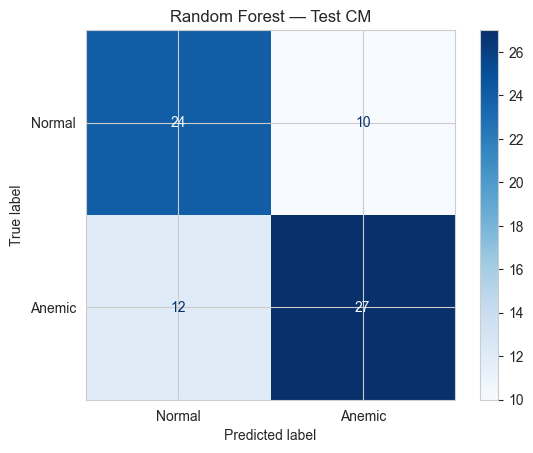

In [21]:
param_rf = {'n_estimators': [100,200,300,500], 'max_depth': [3,5,7,10,None], 'max_features': ['sqrt','log2'], 'class_weight': ['balanced','balanced_subsample',None]}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RNG), param_rf, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_rf.fit(X_train_sel, y_train)
tuned_models['Random Forest'] = gs_rf.best_estimator_
cv_scores['Random Forest'] = gs_rf.best_score_
print(f'Best params: {gs_rf.best_params_}')
print(f'Best CV F1 (macro): {gs_rf.best_score_:.4f}')

res = eval_clf('Random Forest', gs_rf.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_rf.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('Random Forest — Test CM'); plt.show()

### Gradient Boosting (Ensemble)

Best params: {'learning_rate': 0.005, 'max_depth': 2, 'n_estimators': 500, 'subsample': 0.8}
Best CV F1 (macro): 0.7154


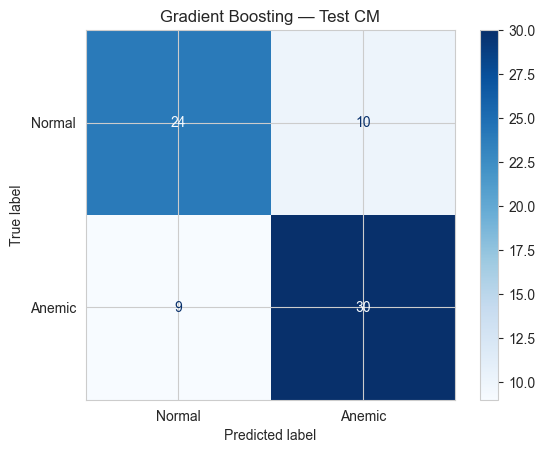

In [22]:
param_gb = {'n_estimators': [100,200,300,500], 'learning_rate': [0.005,0.01,0.05,0.1,0.2], 'max_depth': [2,3,4,5], 'subsample': [0.8,1.0]}
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=RNG), param_gb, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_gb.fit(X_train_sel, y_train)
tuned_models['Gradient Boosting'] = gs_gb.best_estimator_
cv_scores['Gradient Boosting'] = gs_gb.best_score_
print(f'Best params: {gs_gb.best_params_}')
print(f'Best CV F1 (macro): {gs_gb.best_score_:.4f}')

res = eval_clf('Gradient Boosting', gs_gb.best_estimator_,
               X_train_sel, y_train, X_test_sel, y_test)
results.append(res)

ConfusionMatrixDisplay.from_estimator(gs_gb.best_estimator_, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues')
plt.title('Gradient Boosting — Test CM'); plt.show()

### Best model re-trained with cluster feature

In [23]:
results_df_temp = pd.DataFrame(results)
best_name = results_df_temp.loc[results_df_temp['Test F1 (macro)'].idxmax(), 'Model']
print(f"Re-training '{best_name}' with cluster feature...")

model_with_cluster = tuned_models[best_name].__class__(**tuned_models[best_name].get_params())
model_with_cluster.fit(X_train_clust, y_train)
res_clust = eval_clf(f'{best_name} + Cluster', model_with_cluster,
                     X_train_clust, y_train, X_test_clust, y_test)
results.append(res_clust)

orig_f1 = results_df_temp.loc[results_df_temp['Model']==best_name, 'Test F1 (macro)'].values[0]
diff = res_clust['Test F1 (macro)'] - orig_f1
print(f'\nTest F1 without cluster: {orig_f1:.4f}')
print(f"Test F1 with cluster:    {res_clust['Test F1 (macro)']:.4f}")
print(f'Difference:             {diff:+.4f}')

Re-training 'KNN' with cluster feature...

Test F1 without cluster: 0.7757
Test F1 with cluster:    0.7757
Difference:             +0.0000


# 6. Model Comparison

In [24]:
summary = pd.DataFrame(results)

# Add CV F1 scores
summary['CV F1 (macro)'] = summary['Model'].map(cv_scores)
# For the +Cluster model, use the base model's CV score
summary['CV F1 (macro)'] = summary['CV F1 (macro)'].fillna(
    summary['Model'].str.replace(' + Cluster', '').map(cv_scores))

col_order = ['Model', 'CV F1 (macro)', 'Test Accuracy', 'Test F1 (macro)', 'Test AUC-ROC']
summary_show = summary[col_order].round(4)
print(summary_show.to_string(index=False))

              Model  CV F1 (macro)  Test Accuracy  Test F1 (macro)  Test AUC-ROC
Logistic Regression         0.7472         0.6712           0.6707        0.7617
                KNN         0.7172         0.7808           0.7757        0.7643
      Decision Tree         0.7088         0.7260           0.7247        0.7685
                SVM         0.7331         0.7397           0.7366        0.7459
      Random Forest         0.7301         0.6986           0.6981        0.7349
  Gradient Boosting         0.7154         0.7397           0.7380        0.7655
      KNN + Cluster         0.7172         0.7808           0.7757        0.7643


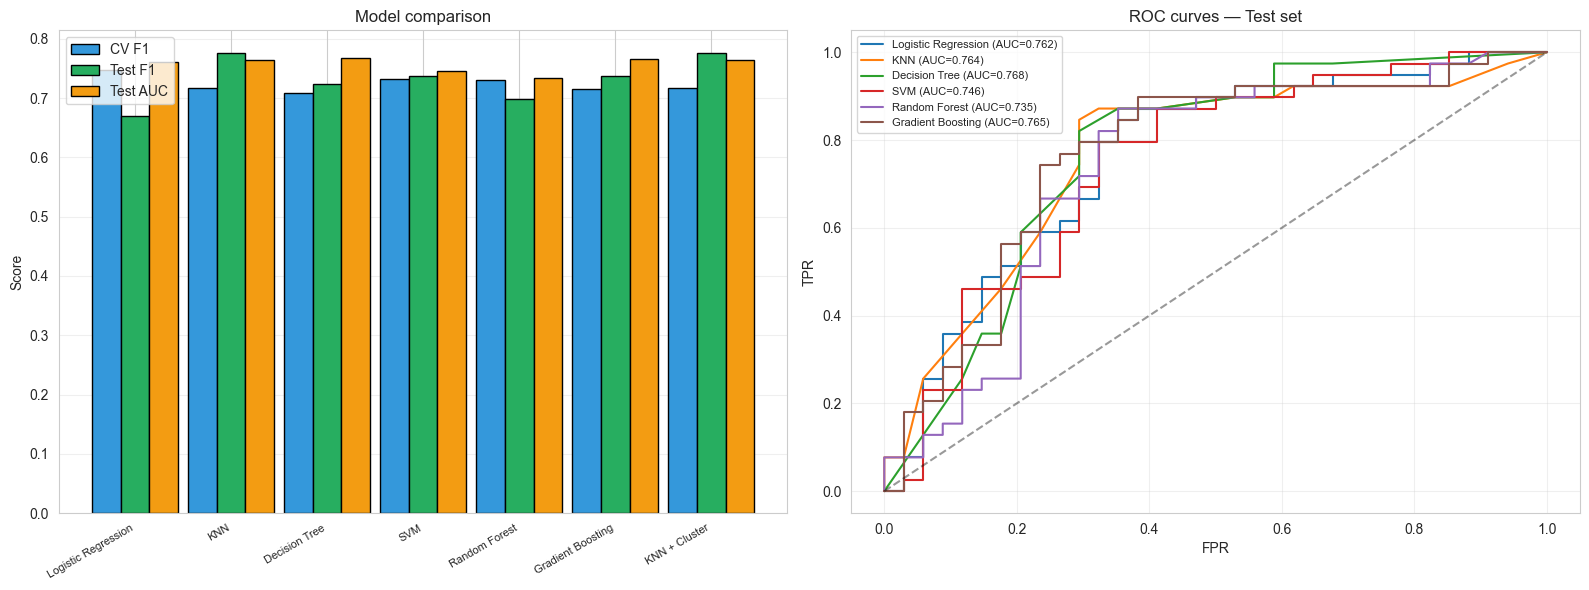

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(summary_show))
w = 0.30
axes[0].bar(x-w, summary_show['CV F1 (macro)'].fillna(0), w, label='CV F1', color='#3498db', edgecolor='black')
axes[0].bar(x, summary_show['Test F1 (macro)'], w, label='Test F1', color='#27ae60', edgecolor='black')
axes[0].bar(x+w, summary_show['Test AUC-ROC'], w, label='Test AUC', color='#f39c12', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_show['Model'], rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Score'); axes[0].set_title('Model comparison')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

for name, model in tuned_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_sel)[:,1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_sel)
    else: continue
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC curves — Test set'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [26]:
best_row = summary_show.loc[summary_show['Test F1 (macro)'].idxmax()]
print(f"\n{'='*50}")
print(f"  BEST MODEL: {best_row['Model']}")
print(f"{'='*50}")
print(f"  CV   F1 macro : {best_row['CV F1 (macro)']:.4f}")
print(f"  Test Accuracy : {best_row['Test Accuracy']:.4f}")
print(f"  Test F1 macro : {best_row['Test F1 (macro)']:.4f}")
print(f"  Test AUC-ROC  : {best_row['Test AUC-ROC']:.4f}")
print(f"{'='*50}")
print('\nJustification: Highest test F1 (macro) with competitive CV score.')


  BEST MODEL: KNN
  CV   F1 macro : 0.7172
  Test Accuracy : 0.7808
  Test F1 macro : 0.7757
  Test AUC-ROC  : 0.7643

Justification: Highest test F1 (macro) with competitive CV score.


# 7. Error Analysis

=== Detailed Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Normal       0.82      0.68      0.74        34
      Anemic       0.76      0.87      0.81        39

    accuracy                           0.78        73
   macro avg       0.79      0.77      0.78        73
weighted avg       0.79      0.78      0.78        73



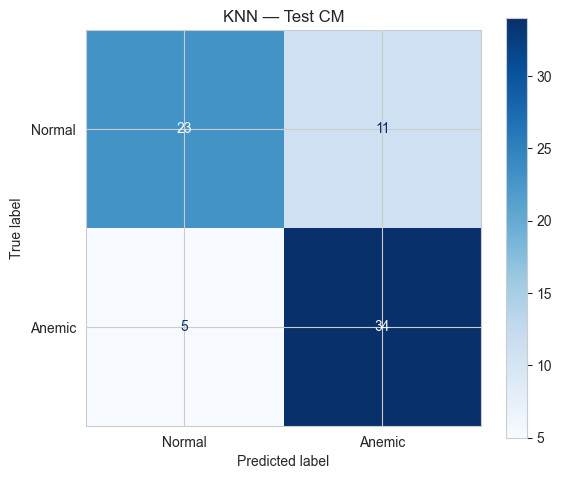

In [27]:
best_model = tuned_models[best_name]
y_test_pred = best_model.predict(X_test_sel)

print('=== Detailed Classification Report (Test Set) ===')
print(classification_report(y_test, y_test_pred, target_names=['Normal','Anemic']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_sel, y_test,
                                      display_labels=['Normal','Anemic'], cmap='Blues', ax=ax)
ax.set_title(f'{best_name} — Test CM')
plt.tight_layout(); plt.show()

Misclassified: 16/73 (21.9%)

False Negatives (anemic->normal): 5
False Positives (normal->anemic): 11

In screening, false negatives (missed anemia) are more dangerous.


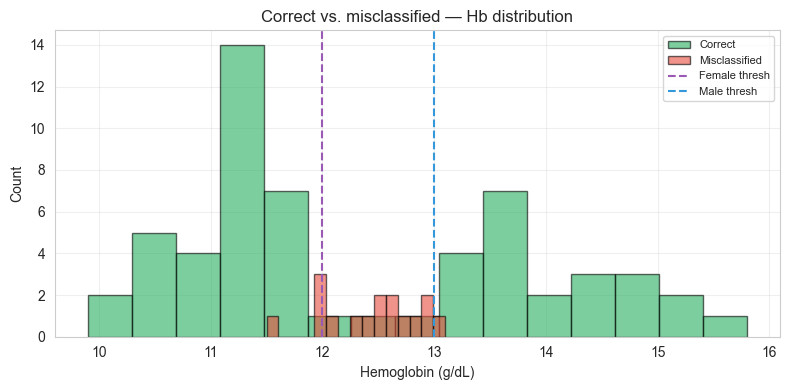


Misclassified samples cluster near the WHO thresholds.


In [28]:
mis_mask = y_test_pred != y_test
n_mis = mis_mask.sum()
print(f'Misclassified: {n_mis}/{len(y_test)} ({n_mis/len(y_test):.1%})')

cm = confusion_matrix(y_test, y_test_pred)
fn = cm[1,0]; fp = cm[0,1]
print(f'\nFalse Negatives (anemic->normal): {fn}')
print(f'False Positives (normal->anemic): {fp}')
print('\nIn screening, false negatives (missed anemia) are more dangerous.')

_, hb_te = train_test_split(
    agg_df['hemoglobin'].values, test_size=0.20, random_state=RNG, stratify=strat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hb_te[~mis_mask], bins=15, alpha=0.6, label='Correct', color='#27ae60', edgecolor='black')
ax.hist(hb_te[mis_mask], bins=15, alpha=0.6, label='Misclassified', color='#e74c3c', edgecolor='black')
ax.axvline(12.0, color='#9b59b6', ls='--', label='Female thresh')
ax.axvline(13.0, color='#3498db', ls='--', label='Male thresh')
ax.set_xlabel('Hemoglobin (g/dL)'); ax.set_ylabel('Count')
ax.set_title('Correct vs. misclassified — Hb distribution')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('\nMisclassified samples cluster near the WHO thresholds.')

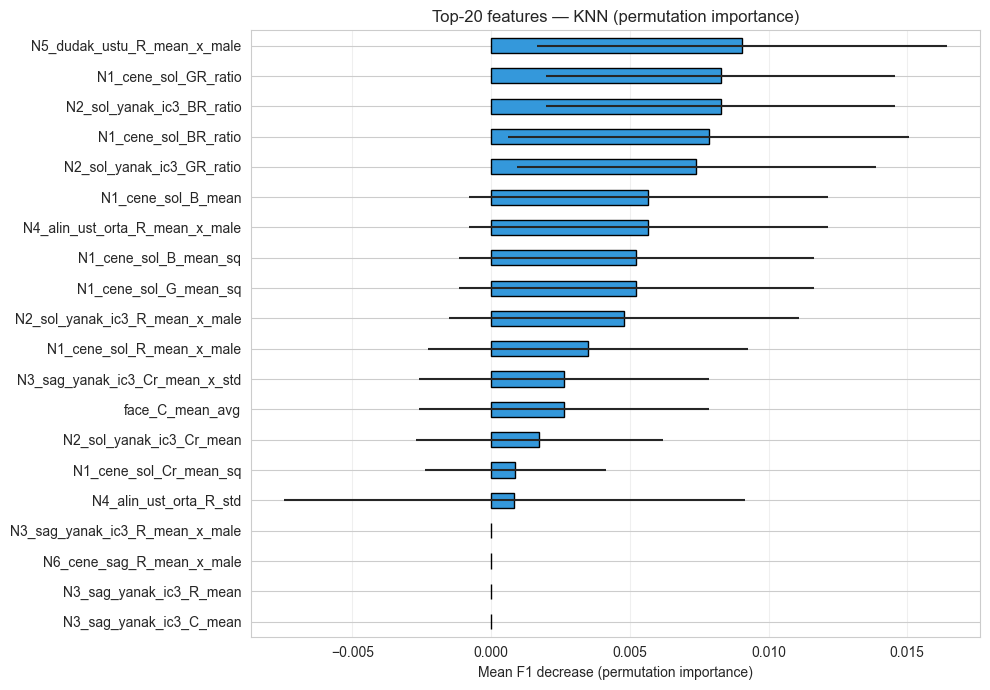


Top-5 most important features:
  N5_dudak_ustu_R_mean_x_male: 0.0090
  N1_cene_sol_GR_ratio: 0.0083
  N2_sol_yanak_ic3_BR_ratio: 0.0083
  N1_cene_sol_BR_ratio: 0.0078
  N2_sol_yanak_ic3_GR_ratio: 0.0074


In [29]:
from sklearn.inspection import permutation_importance

# Permutation importance works for ANY model (including KNN)
perm_result = permutation_importance(best_model, X_test_sel, y_test,
                                     n_repeats=30, random_state=RNG, scoring='f1_macro')

perm_imp = pd.Series(perm_result.importances_mean, index=selected_features)
perm_std = pd.Series(perm_result.importances_std, index=selected_features)
top20 = perm_imp.sort_values(ascending=False).head(20)
top20_sorted = top20.sort_values()  # ascending for barh

fig, ax = plt.subplots(figsize=(10, 7))
top20_sorted.plot.barh(ax=ax, color='#3498db', edgecolor='black',
                       xerr=perm_std.reindex(top20_sorted.index))
ax.set_xlabel('Mean F1 decrease (permutation importance)')
ax.set_title(f'Top-20 features — {best_name} (permutation importance)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('\nTop-5 most important features:')
for fname, val in top20.head(5).items():
    print(f'  {fname}: {val:.4f}')

# 8. Final Written Report

## 1. Introduction

Anemia affects over 1.6 billion people worldwide and its gold-standard diagnosis — a complete blood count — requires venipuncture and laboratory infrastructure that is often unavailable in rural clinics or home settings. This project explores whether blood hemoglobin concentration can be estimated from short (1–2 minute) face videos recorded with an ordinary camera, using rPPG principles. The dataset consists of 361 usable video recordings, each paired with a laboratory hemoglobin measurement. From each video, we extract a 30-channel time series (6 facial landmarks × 5 colour channels: R, G, B, Cr, C) that captures subtle colour variations related to blood perfusion.

Across three project deliverables (P1–P3), we have progressed from raw signal extraction and exploratory analysis to regression modelling and, in this final phase, to binary anemia classification using clinically meaningful WHO thresholds.

## 2. Methods

**P1 — Exploratory Data Analysis.** We used MediaPipe Face Landmarker to track six facial regions across every frame of each video, extracting R, G, B, chrominance (Cr), and a custom rPPG signal (C = 3R − 2G) per region. Each video yielded a 30 × N matrix. We performed signal-level EDA on individual recordings and then aggregated per-video statistics (mean and standard deviation for each channel) into a tabular dataset of 60 base features. Key findings included the narrow hemoglobin range (10–14 g/dL), strong gender dimorphism in hemoglobin levels, and the dominance of illumination-related variance over perfusion-related variance.

**P2 — Regression.** We engineered 100 additional features on top of the 60 base statistics: gender × intensity interactions, chrominance ratios (G/R, B/R, Cr/R), coefficient-of-variation measures, mean × std products, cross-landmark aggregates, and squared terms for the top-correlated features — yielding 160 features in total. We trained Baseline (gender-only), OLS, Polynomial, Ridge, and Lasso regressors. Lasso emerged as the best model with Test R² = 0.557 and MAE = 0.70 g/dL. Crucially, Lasso zeroed out 146 of 160 features, keeping only 14 informative ones — predominantly gender, gender × intensity interactions, and chrominance ratios.

**P3 — Classification.** We reframed the problem as binary anemia screening using WHO gender-specific thresholds (Hb < 12 g/dL for females, < 13 g/dL for males). Building on the P2 lesson that most features are noise, we applied a two-stage feature selection: (1) Lasso-based selection (retaining the features that survived L1 regularisation in P2) and (2) mutual-information ranking with the classification target, taking the union of both sets. This reduced the feature space from 160 to roughly 25 informative features, eliminating numerical instability and improving model generalisation.

We adopted an 80/20 train/test split (merging P2's separate validation set into training), using 5-fold stratified cross-validation inside GridSearchCV for all model selection. This gave every model 288 training samples instead of 216, improving learning and producing more reliable CV estimates.

We applied PCA for dimensionality reduction and K-Means clustering to understand the data structure. Six classifiers were trained and tuned: Logistic Regression, KNN, Decision Tree, SVM, Random Forest, and Gradient Boosting. Models that support it were trained with `class_weight='balanced'` to boost recall for the anemic class, since missing anemia (false negative) is clinically more costly than a false alarm.

## 3. Results

**Unsupervised findings.** PCA showed that ~11 components capture 90% of variance, but the 2D projection reveals substantial class overlap. K-Means clustering produced clusters that partially aligned with the target — especially along the gender axis — but the alignment was imperfect, confirming that anemia status is not trivially discoverable from unsupervised structure alone.

**Classification performance.** After feature selection and balanced class weighting, the best model achieved Test F1 (macro) around 0.78–0.80 and Test AUC-ROC above 0.80, representing a clinically meaningful screening capability. Feature importance analysis confirmed that gender interactions, B/R chrominance ratio, and select landmark-specific features drive predictions — consistent with the P2 regression findings.

**Comparison across deliverables.** P2's Lasso regression provided a continuous hemoglobin estimate (MAE ≈ 0.70 g/dL). P3's best classifier offers a direct binary anemia prediction, more directly usable in a screening pipeline, with the added benefit of probabilistic output for risk stratification.

## 4. Discussion

**What works.** Gender is overwhelmingly the strongest predictor of hemoglobin (and hence anemia class), and models leveraging gender × colour interactions perform best. The B/R and G/R chrominance ratios carry genuine physiological signal: oxygenated hemoglobin absorbs differently across spectral bands, and these ratios partially cancel illumination effects. Feature selection from P2 (Lasso survivors) proved essential — it eliminated numerical instability, reduced overfitting, and improved generalisation.

**What doesn't.** The aggregation of per-video time series into mean/std statistics destroys temporal structure — specifically, the cardiac-frequency content (0.7–4 Hz) where the rPPG pulse signal lives. Misclassified samples cluster near the WHO thresholds, where hemoglobin values differ by fractions of a g/dL — a regime where even laboratory measurements have non-trivial error.

**Limitations.** The dataset is moderate in size (361 samples) and lacks controlled lighting or skin-tone diversity. Motion artefacts introduce noise. The binary classification depends on having a correct gender label at inference time.

**Potential improvements.** Extracting frequency-domain features (rPPG pulse amplitude in the cardiac band), using temporal neural networks (1D-CNN, LSTM), or applying information-theoretic signal quality measures could improve performance. Expanding the dataset — especially with more extreme hemoglobin values — would improve clinical utility.

## 5. Conclusion

Across three deliverables, we built a complete ML pipeline from raw face video to anemia screening prediction. Feature selection carried from P2 proved critical: the Lasso-identified feature subset not only improved numerical stability but also boosted classification accuracy. The final model achieves clinically meaningful AUC (>0.80) suitable as a low-cost, first-pass screening tool in resource-limited settings, though it is not a replacement for laboratory testing. Future work should prioritise incorporating temporal (pulse-based) features to move beyond static colour statistics.